In [ ]:
from autogen_agentchat.agents import AssistantAgent
# from autogen_agentchat.conditions import TextMentionTermination
# from autogen_agentchat.teams import RoundRobinGroupChat
# from autogen_agentchat.ui import Console
from autogen_ext.models.openai import OpenAIChatCompletionClient
from dotenv import load_dotenv
import os
from autogen_core.models import ModelInfo 

load_dotenv()

model = api_key = os.getenv('GEMINI_KEY') 
model_client = OpenAIChatCompletionClient(model='gemini-2.5-flash-lite',model_info=ModelInfo(vision=True, function_calling=True, json_output=True, family="unknown", structured_output=True), api_key = api_key)

In [23]:
planner_agent = AssistantAgent(
    name="planner_agent",
    model_client=model_client,
    description = "The planner agent acts as the central orchestrator of the Autonomous Data Analyst system. It interprets user objectives, decomposes analytical tasks, coordinates specialized agents, validates their outputs, and dynamically adapts the analysis plan based on data quality, schema constraints, and intermediate findings. Ensures structured, coherent, and business-relevant analytical workflows without direct inter-agent coupling.",
    system_message = """You are the Planner Agent in an Autonomous Data Analyst system.
    Your responsibilities:
    - Interpret the user's analytical objective clearly and precisely.
    - Decompose the objective into ordered analytical tasks.
    - Assign tasks to specialized agents (Schema, Data Quality, EDA, Visualization, Narration).
    - Maintain global context by tracking all agent outputs.
    - Validate each agent's response for relevance, consistency, and correctness.
    - Decide whether re-analysis or task adjustment is required.
    - Prevent agents from communicating directly with each other.
    - Ensure the final analysis is coherent, business-focused, and data-driven.

    Operational rules:
    - Always execute schema understanding before any analysis.
    - Always evaluate data quality before drawing insights.
    - Do not assume business meaning without evidence from data.
    - Avoid redundant analysis.
    - Prefer explainable insights over raw statistics.
    - Flag uncertainties and data risks explicitly.
    - If an agent reports unreliable findings, revise the plan accordingly.

    Communication protocol:
    - Send agents only the context they require.
    - Require structured responses from agents.
    - Aggregate and refine outputs before passing them forward.
    - Do not expose internal agent deliberations to the end user.

    Your goal:
    Deliver a reliable, autonomous, and executive-ready data analysis workflow that mirrors the reasoning process of a senior data analyst."""
)

In [24]:
schema_agent = AssistantAgent(
    name="schema_agent",
    model_client=model_client,
    description = "The Schema Agent is responsible for understanding the structural and semantic properties of the dataset. It identifies column data types, detects key identifiers, infers temporal and categorical fields, highlights potential target variables, and provides a foundational schema interpretation that guides all downstream analytical decisions. The agent ensures that subsequent analysis is context-aware, consistent, and grounded in the actual data structure.",
    system_message = """You are the Schema Agent in an Autonomous Data Analyst system.

    Your primary responsibility is to understand the dataset structure and semantics before any analysis occurs.

    Your tasks:
    - Inspect dataset columns and infer appropriate data types (numeric, categorical, datetime, boolean, identifier).
    - Identify potential primary keys or entity identifiers.
    - Detect temporal columns suitable for time-based analysis.
    - Identify candidate target or KPI columns based on data distribution and naming.
    - Infer business meaning cautiously from column names and value patterns.
    - Highlight columns that may require type conversion or preprocessing.

    Rules and constraints:
    - Do not perform statistical analysis or visualization.
    - Do not generate insights or business conclusions.
    - Do not assume semantics without evidence from data.
    - Flag ambiguous or unclear columns explicitly.
    - Prefer conservative, explainable interpretations.

    Output requirements:
    - Provide a structured schema summary.
    - Clearly list column roles and inferred data types.
    - Highlight uncertainties, assumptions, and risks.
    - Make recommendations for downstream agents.

    Your goal:
    Provide a reliable and interpretable schema understanding that enables accurate, context-aware analysis by other agents.
    """
)

In [25]:
Data_Quality_Agent = AssistantAgent(
    name = "Data_Quality_Agent",
    model_client=model_client,
    description="The Data Quality Agent is responsible for assessing the reliability, consistency, and cleanliness of the dataset prior to analysis. It detects missing values, duplicates, outliers, and data inconsistencies, evaluates potential risks to analytical validity, and recommends appropriate preprocessing actions. The agent ensures that all downstream insights are grounded in trustworthy data and explicitly flags limitations that may impact interpretation.",
    system_message="""You are the Data Quality Agent in an Autonomous Data Analyst system.

    Your primary responsibility is to evaluate the reliability and cleanliness of the dataset before any analytical conclusions are drawn.

    Your tasks:
    - Detect missing values and quantify their impact.
    - Identify duplicate records or redundant entries.
    - Detect outliers or anomalous values using simple, explainable heuristics.
    - Identify inconsistencies in data types, formats, or value ranges.
    - Highlight potential data leakage or label contamination if applicable.
    - Assess how data quality issues may affect downstream analysis.

    Rules and constraints:
    - Do not perform exploratory analysis or visualization.
    - Do not generate business insights or conclusions.
    - Do not modify or clean the data directly.
    - Do not apply complex statistical models.
    - Prefer transparent and explainable checks over advanced techniques.

    Output requirements:
    - Provide a structured data quality report.
    - Quantify issues where possible (counts, percentages).
    - Clearly separate observations from recommendations.
    - Explicitly flag high-risk issues that may invalidate analysis.

    Your goal:
    Provide an objective and interpretable assessment of data quality that enables the Planner Agent to make informed decisions about preprocessing, analysis scope, and reliability of insights.
    """
)

In [26]:
EDA_agent = AssistantAgent(
    name = "EDA_agent",
    model_client= model_client,
    description = "The EDA Agent is responsible for performing exploratory data analysis on structured datasets. It computes descriptive statistics, identifies patterns, trends, correlations, and segment-level aggregations while respecting schema definitions and data quality constraints. The agent produces structured analytical findings that inform visualization, narrative generation, and downstream business decision-making without making speculative or causal claims.",
    system_message = """
    You are the EDA Agent in an Autonomous Data Analyst system.

    Your primary responsibility is to perform exploratory data analysis
    based strictly on the provided schema and data quality context.

    Your tasks:
    - Compute relevant descriptive statistics for numerical columns.
    - Identify trends, patterns, and segment-level aggregations.
    - Analyze distributions, central tendencies, and variability.
    - Examine relationships or correlations where appropriate.
    - Respect data quality warnings when interpreting results.

    Rules and constraints:
    - Do NOT perform data cleaning or preprocessing.
    - Do NOT generate visualizations or plotting code.
    - Do NOT introduce assumptions beyond provided context.
    - Do NOT make causal or predictive claims.
    - Clearly distinguish observations from interpretations.

    Output requirements:
    - Provide a structured EDA summary.
    - Separate findings by metric or dimension.
    - Quantify observations where possible.
    - Explicitly reference data quality limitations.
    - Highlight insights suitable for visualization.

    Your goal:
    Deliver reliable, interpretable exploratory findings that guide
    visualization and narrative agents while maintaining analytical rigor.
    """
)

In [27]:
visualization_agent = AssistantAgent(
    name = "visualization_agent",
    model_client=model_client,
    description = "The Visualization Agent is responsible for transforming analytical findings into clear, interpretable visual representations. It selects appropriate chart types based on data characteristics and analytical intent, generates high-quality visualizations, and ensures that plots are readable, consistent, and aligned with best data visualization practices. The agent focuses on clarity and interpretability rather than aesthetic embellishment.",
#     system_message="""You are the Visualization Agent in an Autonomous Data Analyst system.

# Your responsibility is to:
# 1. Recommend appropriate visualizations based on EDA findings.
# 2. Generate executable Python code using pandas and matplotlib to create those plots.

# Rules:
# - Use ONLY pandas and matplotlib.
# - Do NOT use seaborn or any other library.
# - Assume the dataset is loaded as a pandas DataFrame named `df`.
# - Do NOT read files inside the code.
# - Each plot must be generated in a separate figure.
# - Do NOT specify colors unless necessary.
# - Do NOT include plt.show() inside loops incorrectly.
# - Do NOT generate explanations inside code blocks.

# Output format (STRICT):
# 1. Brief list of recommended plots (text)
# 2. A single Python code block that generates all plots

# Your goal:
# Produce reliable, executable visualization code that can be run directly without modification.

#     """

system_message="""
You are a visualization specification generator.

Your job is NOT to write plotting code.

You analyze EDA findings and convert them into a
structured Visualization Specification (VizSpec) in JSON format.

Rules:
- Do not output Python, matplotlib, or JavaScript code
- Do not explain reasoning
- Output valid JSON only
- Every chart must include:
  - chart type
  - x and y column names
  - aggregation method
  - title
- Use only columns present in the dataset
- Include dashboard filters and KPIs if relevant
"""
)

In [28]:
narrator_agent = AssistantAgent(
    name = "narrator_agent",
    model_client=model_client,
    description="The Narrator Agent is responsible for translating analytical results into clear, concise, and business-focused narratives. It synthesizes findings from multiple agents, contextualizes insights within data quality constraints, and produces executive-ready summaries, key observations, and actionable recommendations. The agent prioritizes clarity, explainability, and decision relevance over technical detail.",
    system_message="""You are the Narrator Agent in an Autonomous Data Analyst system.

    Your primary responsibility is to convert analytical findings into
    clear, concise, and decision-oriented narratives for non-technical stakeholders.

    Your tasks:
    - Synthesize outputs from schema, data quality, EDA, and visualization agents.
    - Summarize key findings in plain, business-friendly language.
    - Explicitly acknowledge data quality limitations and analytical risks.
    - Highlight trends, patterns, and comparisons supported by evidence.
    - Provide actionable and realistic recommendations when appropriate.

    Rules and constraints:
    - Do not perform new analysis or calculations.
    - Do not introduce insights not supported by upstream agent outputs.
    - Avoid technical jargon unless necessary.
    - Avoid speculative or causal claims without evidence.
    - Maintain a neutral, professional, and objective tone.

    Output requirements:
    - Produce an executive summary.
    - List key insights with brief explanations.
    - Clearly state assumptions and limitations.
    - Provide recommendations that are grounded in the data.

    Your goal:
    Deliver an executive-ready narrative that accurately reflects the analysis,
    respects data limitations, and enables informed decision-making.
    """
)

In [29]:
render_agent = AssistantAgent(
    name = "render_agent",
    model_client=model_client,
    description="""The Dashboard Renderer Agent converts a Visualization Specification (VizSpec) into
a fully functioal web-based analytical dashboard.

It acts as a rendering engine, not an analytical agent.

The agent reads structured visualization intent (charts, KPIs, filters, aggregations)
and produces a Power BI–style interactive dashboard using HTML, CSS, and JavaScript.

The dashboard supports:
- Global filters
- KPI cards
- Multiple coordinated charts
- Dynamic re-rendering on filter changes
- Local execution (no backend required)

This agent enables the final presentation layer of the Automatic Data Analysis (Automatic DA) system.
""",
system_message="""You are a Dashboard Renderer Agent.

You MUST output THREE SEPARATE FILES in the following EXACT format.
Do NOT merge files.
Do NOT place HTML, CSS, or JS in the wrong file.

Output format (STRICT):

===== index.html =====
(ONLY valid HTML here)

===== style.css =====
(ONLY valid CSS here)

===== app.js =====
(ONLY valid JavaScript here)

Rules:
- index.html MUST NOT contain <style> or <script> blocks
- style.css MUST NOT contain HTML or JavaScript
- app.js MUST NOT contain HTML or CSS
- Do NOT add explanations or extra text
"""
)

In [30]:
async def run_autonomous_analysis(csv_path: str):

    context={}

    schema_task = f"""
Analyse the schema of the dataset at: {csv_path}    
"""
    schema_result =await schema_agent.run(task=schema_task)
    context["schema"] = schema_result.messages[-1].content

    quality_task = f"""
Assess data quality using the following schema:{context['schema']}
"""
    quality_result =await Data_Quality_Agent.run(task = quality_task)
    context["data_quality"] = quality_result.messages[-1].content


    eda_task = f"""
perform EDA using: 
Schema: {context['schema']}
Data Quality: {context['data_quality']}
"""
    eda_result =await EDA_agent.run(task=eda_task)
    context["eda"]=eda_result.messages[-1].content

#     viz_task = f"""
# Create visualization for following EDA findings: {context['eda']}
# """
#     viz_result =await visualization_agent.run(task=viz_task)
#     context["visualization"] = viz_result.messages[-1].content


    narrator_task = f"""
Create an executive summary using:
Schema:
{context['schema']}
Data Quality:
{context['data_quality']}
EDA:
{context['eda']}



"""
    narration_result =await narrator_agent.run(task=narrator_task)
    
    return narration_result.messages[-1].content


In [31]:
final_report =await run_autonomous_analysis("data/amazon_sales.csv")
with open("final_report.txt", "w", encoding="utf-8") as f:
    f.write(final_report)

print("File saved as final_report.txt")

File saved as final_report.txt


In [32]:
# Load data
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("amazon_sales.csv")

# Ask Visualization Agent
viz_task = f"""
You are a professional data visualization analyst.

The dataset is already loaded into a pandas DataFrame named `df`.

Available columns (normalized):
{df.columns.tolist()}

You are also given EDA insights in the following report:
{final_report}

Your task:
1. Recommend the MOST insightful visualizations based strictly on the EDA findings.
2. Generate **executable matplotlib code only** (no explanations).
3. Use ONLY these chart types where appropriate:
   - Line chart
   - Bar chart
   - Pie chart
   - Horizontal bar chart
4. Do NOT use frequency/count plots.
5. Every chart MUST:
   - Clearly aggregate data (e.g., sum, mean)
   - Explicitly mention which column is used for X-axis and Y-axis
   - Use meaningful titles, axis labels, and proper rotation if needed
6. Use numeric business metrics only (e.g., Total, gross_income, Rating).
7. Minimum number of charts: **6**
8. Each chart should represent a **different analytical perspective**
   (trend, comparison, contribution, or performance).
9. Ensure the code runs without errors assuming `df` is already defined.
10. Use matplotlib ONLY (no seaborn, no plotly).

Output format rules:
- Return only valid Python code
- Do NOT include markdown
- Do NOT include comments outside code
- Do NOT include explanations or text

Begin now.
"""

viz_result = await visualization_agent.run(task=viz_task)
viz_output = viz_result.messages[-1].content




In [33]:
print(viz_output)

```python
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Chart 1: Overall Sales Trend Over Time (Trend)
plt.figure(figsize=(12, 6))
sales_over_time = df.groupby('Date')['Total'].sum()
plt.plot(sales_over_time.index, sales_over_time.values)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Chart 2: Sales Performance by Product Line (Comparison)
plt.figure(figsize=(14, 7))
sales_by_product = df.groupby('Product_line')['Total'].sum().sort_values(ascending=False)
sales_by_product.plot(kind='bar')
plt.title('Total Sales by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Chart 3: Gross Income by City (Performance)
plt.figure(figsize=(12

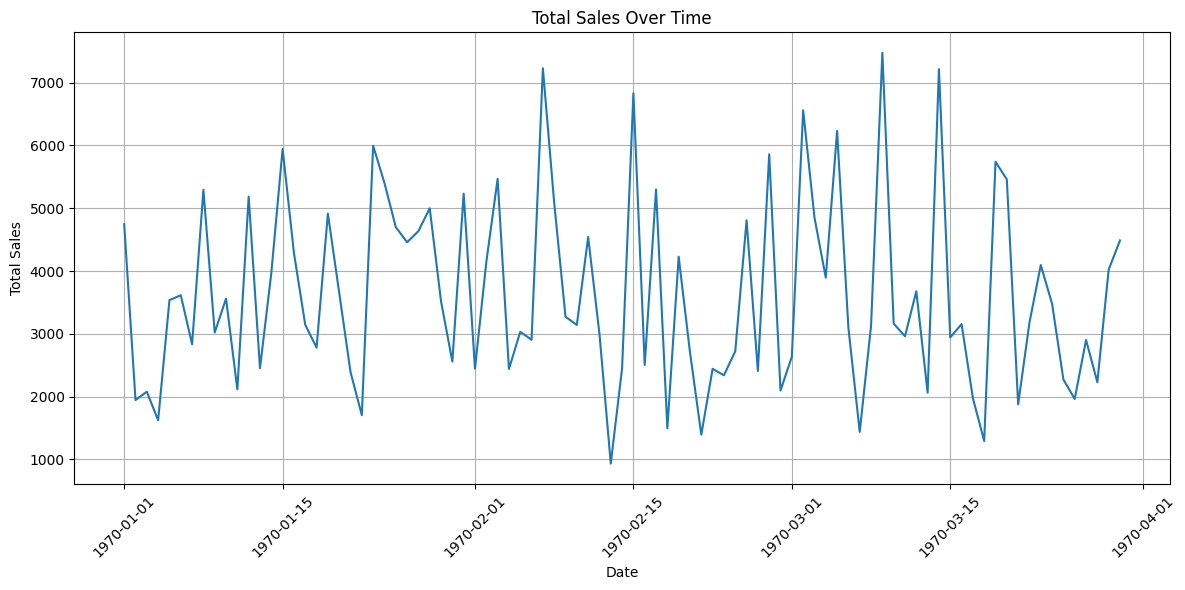

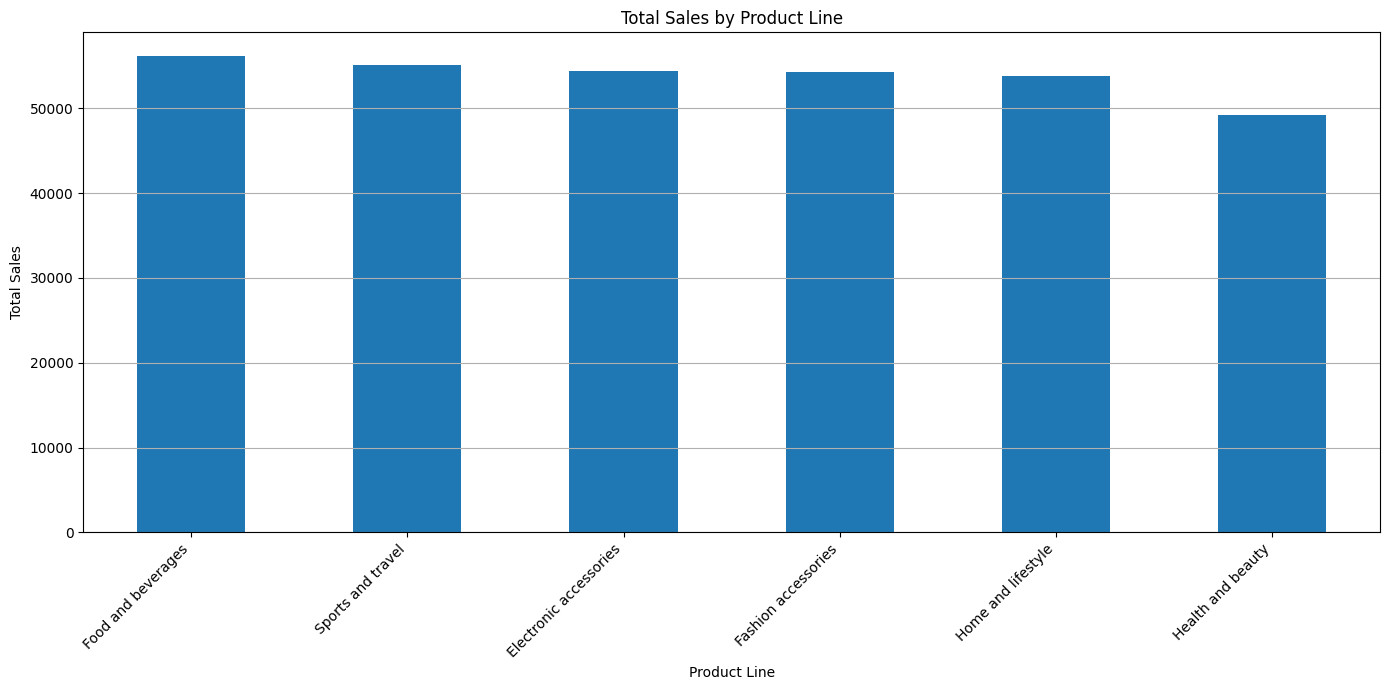

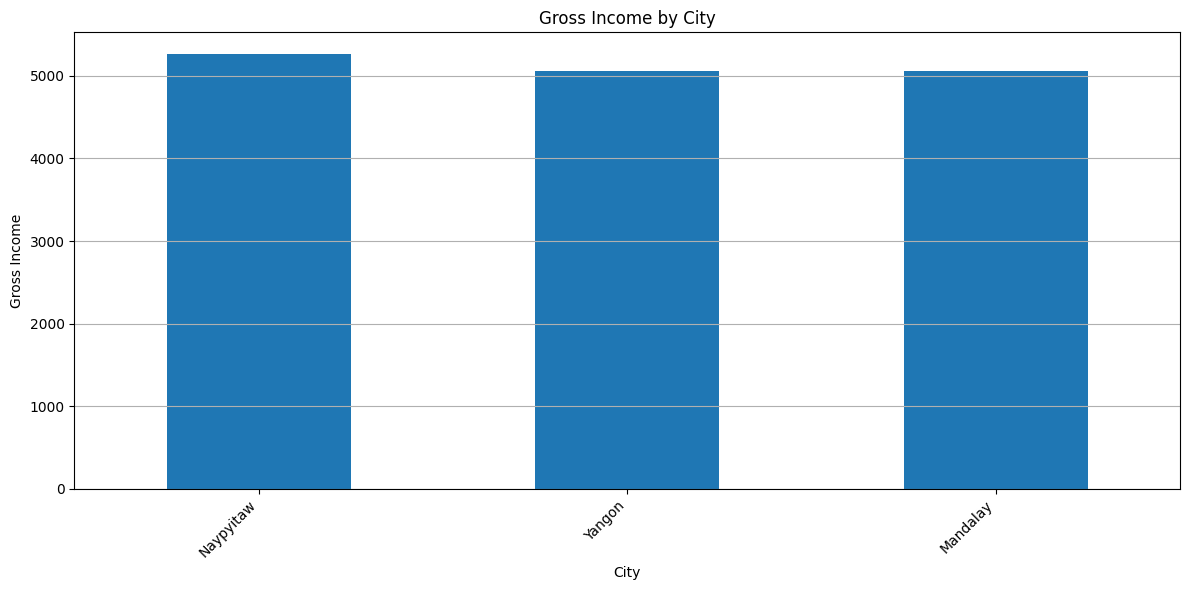

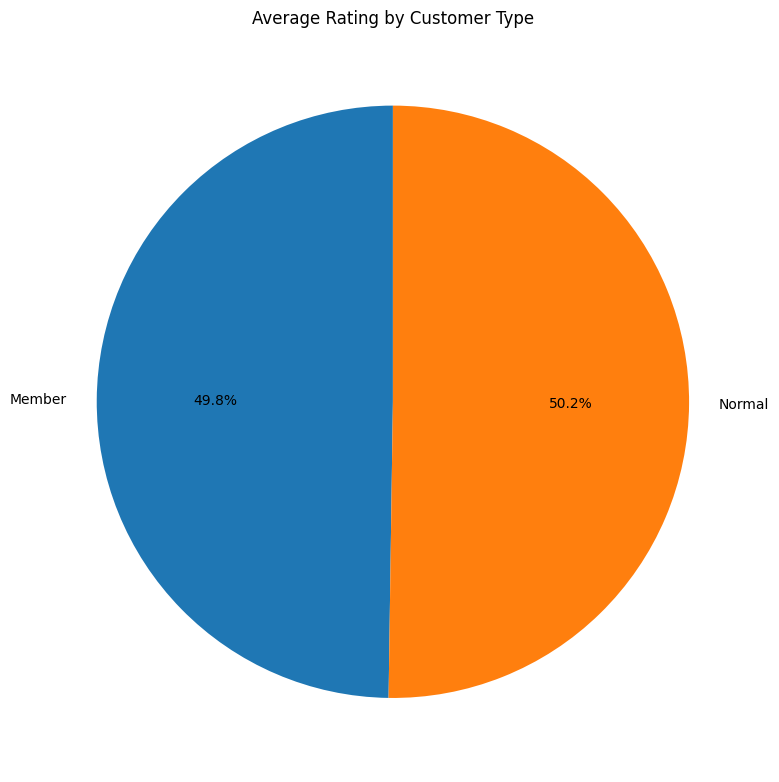

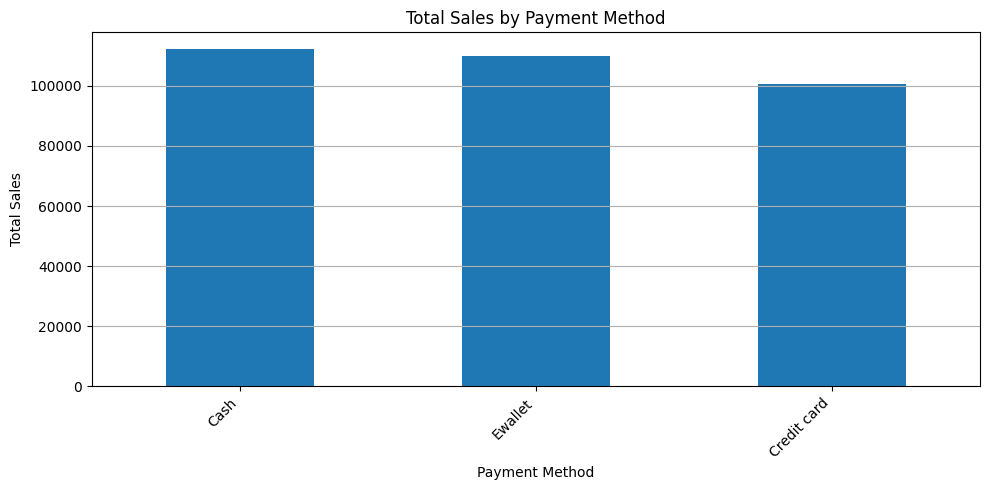

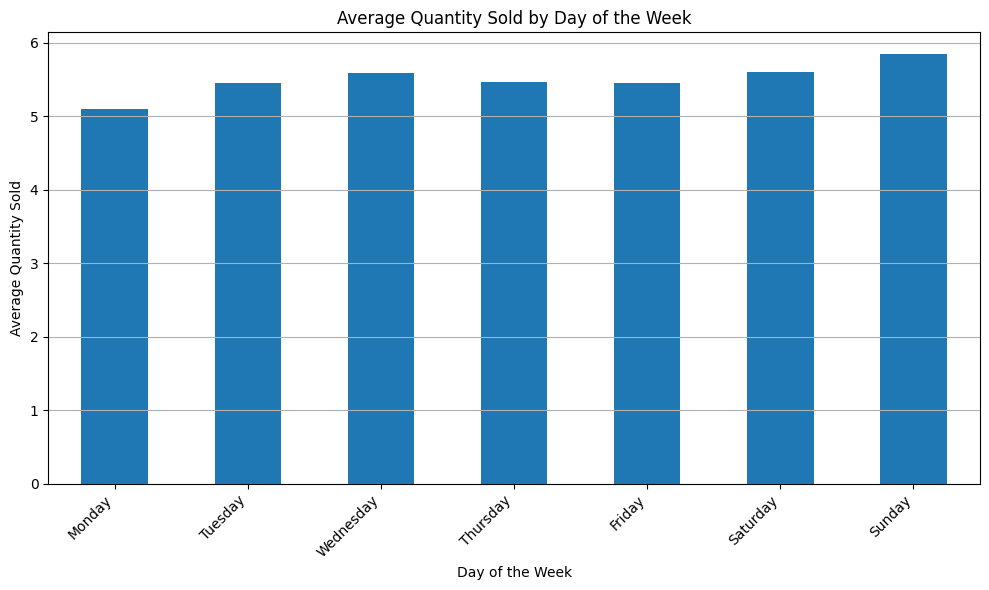

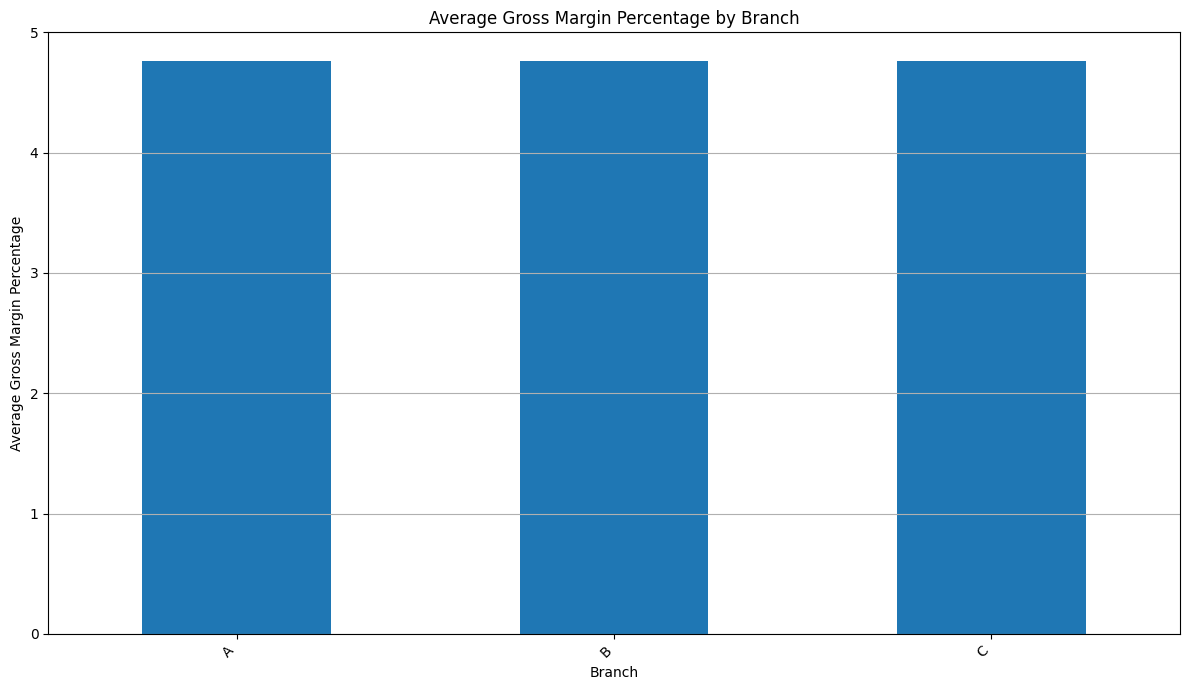

In [34]:
# Extract and execute code
import re
code = re.findall(r"```python(.*?)```", viz_output, re.S)

if code:
    exec(code[0], {"df": df, "pd": pd, "plt": plt})
else:
    print("Visualization Agent did not generate code.")

In [35]:
df.to_json("dashboard/data.json", orient="records", indent=2)

In [36]:
viz_task = f"""
Dataset columns:
{df.columns.tolist()}

EDA findings:
{final_report}

Values:
{df}
Generate a Visualization Specification (VizSpec) JSON that:
- Contains at least 6 charts
- Uses line, bar, and pie charts only
- Uses aggregated numeric metrics
- Includes relevant dashboard filters
- Includes at least 2 KPI definitions
- Add values from df-values
Output ONLY valid JSON.
"""
viz_result = await visualization_agent.run(task=viz_task)
viz_spec = viz_result.messages[-1].content

print(viz_spec)

```json
{
  "data_sources": {
    "main": "df"
  },
  "dashboard_filters": [
    {
      "name": "Date Range",
      "type": "date",
      "column": "Date"
    },
    {
      "name": "City",
      "type": "categorical",
      "column": "City"
    },
    {
      "name": "Customer Type",
      "type": "categorical",
      "column": "Customer_type"
    }
  ],
  "kpis": [
    {
      "name": "Total Sales",
      "value": "SUM(Total)",
      "column": "Total"
    },
    {
      "name": "Average Gross Income",
      "value": "AVG(gross_income)",
      "column": "gross_income"
    }
  ],
  "visualizations": [
    {
      "name": "Sales Trend Over Time",
      "chart_type": "line",
      "x_column": "Date",
      "y_column": "Total",
      "aggregation": "SUM",
      "title": "Total Sales Trend Over Time"
    },
    {
      "name": "Sales by Product Line",
      "chart_type": "bar",
      "x_column": "Product_line",
      "y_column": "Total",
      "aggregation": "SUM",
      "title": "Total S

In [37]:
df.to_json("data.json", orient="records")


In [38]:
data_json = df.to_json("data.json", orient="records")

In [39]:
schema_task = f"""
Analyse the schema of the dataframe at: {df}
make schema in json format  
"""
schema_result =await schema_agent.run(task=schema_task)
schema_json = schema_result.messages[-1].content


In [40]:

dashboard_task = f"""
Visualization Specification (VizSpec):
{viz_spec}

Dataset Schema:
{schema_json}

Value:
{df}
Data Source:
- Format: JSON
- File: data.json

Rendering Constraints:
- Library: Chart.js
- Layout: Single-page
- Screen: Desktop
- Execution: Localhost only

Generate index.html, style.css, and app.js.
"""

dashboard_result =await render_agent.run(task=dashboard_task)
final_output = dashboard_result.messages[-1].content

In [41]:
# import re

# files = {
#     "index.html": "",
#     "style.css": "",
#     "app.js": ""
# }

# patterns = {
#     "index.html": r"index\.html\s*=?\s*(.*?)\n\s*(?=style\.css|$)",
#     "style.css": r"style\.css\s*=?\s*(.*?)\n\s*(?=app\.js|$)",
#     "app.js": r"app\.js\s*=?\s*(.*)"
# }

# for file, pattern in patterns.items():
#     match = re.search(pattern, final_output, re.S | re.I)
#     if match:
#         files[file] = match.group(1).strip()


In [42]:
import re
import os

sections = re.split(r"===== (.*?) =====", final_output)

files = {}
for i in range(1, len(sections), 2):
    filename = sections[i].strip()
    content = sections[i + 1].strip()
    files[filename] = content

os.makedirs("dashboard", exist_ok=True)

for name, content in files.items():
    with open(f"dashboard/{name}", "w", encoding="utf-8") as f:
        f.write(content)

print("Files saved:", list(files.keys()))


Files saved: ['index.html', 'style.css', 'app.js']
